In [1]:
import math
import numpy as np
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
from enum import Enum

# Donchian Channel strategy

In [2]:
df_GOLD_Raw = pd.read_parquet(f"../Data/GOLD_1M.parquet")
df_baseline = pd.read_parquet(f"../Data/EURUSD_M1.parquet")
df_GOLD_Raw.head()

,open,high,low,close,volume
time,,,,,
2019-10-15 12:13:00,1492.87,1493.36,1492.77,1493.33,62
2019-10-15 12:14:00,1493.36,1493.47,1493.06,1493.07,47
2019-10-15 12:15:00,1493.09,1493.28,1492.97,1493.07,70
2019-10-15 12:16:00,1493.08,1493.35,1493.07,1493.35,28
2019-10-15 12:17:00,1493.30,1493.36,1493.14,1493.28,38


In [3]:
def get_resampled(df, high_freq='4h'):
    volume_col = 'tick_volume' if 'tick_volume' in df.columns else 'volume'

    df_high_sample_rate = df.resample(high_freq).agg(
        open=('open', 'first'),
        high=('high', 'max'),
        low=('low', 'min'),
        close=('close', 'last'),
        volume=(volume_col, 'sum'),
        High_time=('high', lambda x: x.idxmax() if len(x) > 0 else None),
        Low_time=('low', lambda x: x.idxmin() if len(x) > 0 else None)
    )

    df_high_sample_rate = df_high_sample_rate.dropna()

    return df_high_sample_rate

In [4]:
df_GOLD = get_resampled(df_GOLD_Raw, high_freq="5min")
df_baseline = get_resampled(df_baseline, high_freq="5min")

# Show Strategy

In [5]:
# Create features
if not isinstance(df_GOLD.index, pd.DatetimeIndex):
    if "dateTime" in df_GOLD.columns:
        df_GOLD["date"] = pd.to_datetime(df_GOLD["dateTime"])
        df_GOLD = df_GOLD.set_index("date")
    elif "time" in df_GOLD.columns:
        df_GOLD["date"] = pd.to_datetime(df_GOLD["time"])
        df_GOLD = df_GOLD.set_index("date")
    else:
        df_GOLD.index = pd.to_datetime(df_GOLD.index)

df_GOLD[["dcl", "dcm", "dcu"]] = df_GOLD.ta.donchian(lower_length=40, upper_length=50)
df_GOLD = df_GOLD.dropna().drop(columns=["time", "dateTime"], errors="ignore")

df_GOLD.tail()

,open,high,low,close,volume,High_time,Low_time,dcl,dcm,dcu
time,,,,,,,,,,
2025-12-31 21:35:00,4311.95,4315.74,4311.43,4315.67,554,2025-12-31 21:39:00,2025-12-31 21:35:00,4304.46,4317.91,4331.36
2025-12-31 21:40:00,4315.71,4316.28,4314.11,4314.63,464,2025-12-31 21:42:00,2025-12-31 21:43:00,4304.46,4317.91,4331.36
2025-12-31 21:45:00,4314.63,4316.17,4313.77,4314.43,447,2025-12-31 21:45:00,2025-12-31 21:49:00,4304.46,4317.91,4331.36
2025-12-31 21:50:00,4314.43,4317.15,4314.09,4317.15,461,2025-12-31 21:54:00,2025-12-31 21:53:00,4304.46,4317.91,4331.36
2025-12-31 21:55:00,4317.16,4318.86,4316.89,4318.81,499,2025-12-31 21:58:00,2025-12-31 21:56:00,4304.46,4317.91,4331.36


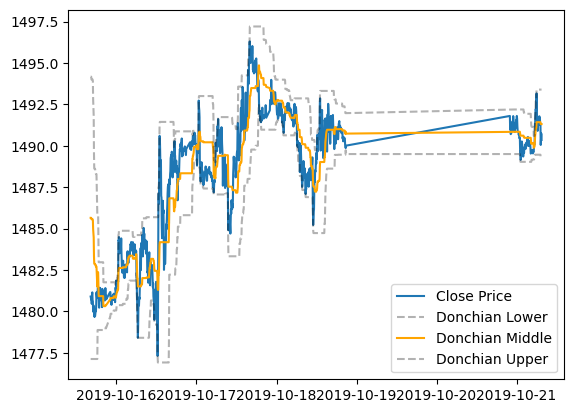

In [6]:
# Plot the price and the Donchian Channels
plt.plot(df_GOLD.close[:1000], label='Close Price')
plt.plot(df_GOLD.dcl[:1000], label='Donchian Lower', color='black', alpha = 0.3, linestyle='--')
plt.plot(df_GOLD.dcm[:1000], label='Donchian Middle', color='orange')
plt.plot(df_GOLD.dcu[:1000], label='Donchian Upper', color='black', alpha = 0.3, linestyle='--')
plt.legend()
plt.show()

## Backtesting strategy

In [7]:
class TimeFrame(Enum):
  DAILY = 252
  MIN_1 = 252 * 24 * 60
  MIN_5 = 252 * 24 * 12
  MIN_10 = 252 * 24 * 6
  HOUR_1 = 252 * 24
  HOUR_6 = 252 * 4

selected_timeframe = TimeFrame.MIN_5

def drawdown_function(returns):

  # Build an equity curve from periodic returns, then compute peak-to-trough drawdown
  equity_curve = (1 + returns.dropna()).cumprod()
  running_max = equity_curve.cummax()
  drawdown = equity_curve / running_max - 1
  return drawdown

def BackTest(strategy_data, baseline_data, annualiazed_scalar=selected_timeframe, plot=True):

  # Accept either enum or numeric annualization scalar
  annualized_scalar = annualiazed_scalar.value if isinstance(annualiazed_scalar, Enum) else float(annualiazed_scalar)

  # Ensure a clean strategy return series
  serie = strategy_data.copy()
  if isinstance(serie, pd.DataFrame):
    if "return" in serie.columns:
      serie = serie["return"]
    else:
      serie = serie.iloc[:, 0]
  serie = serie.rename("return").dropna()
  if not serie.index.is_unique:
    serie = serie[~serie.index.duplicated(keep="first")]

  # Build benchmark return series from close prices
  if isinstance(baseline_data, pd.DataFrame):
    if "close" in baseline_data.columns:
      baseline_price = baseline_data["close"]
    else:
      baseline_price = baseline_data.iloc[:, 0]
  else:
    baseline_price = baseline_data

  baseline = baseline_price.pct_change(1).rename("EURUSD").dropna()
  if not baseline.index.is_unique:
    baseline = baseline[~baseline.index.duplicated(keep="first")]

  # Align by timestamps to avoid mixing unrelated bars
  val = pd.concat((serie, baseline), axis=1, join="inner").dropna()
  if val.empty:
    raise ValueError("No overlapping timestamps between strategy and benchmark after alignment.")

  # Final compounded returns
  final_return_portfolio = (1 + val["return"]).prod() - 1
  final_return_benchmark = (1 + val["EURUSD"]).prod() - 1

  # Compute drawdown on aligned strategy returns
  drawdown = drawdown_function(val["return"]) * 100

  # Compute max drawdown
  max_drawdown = -np.min(drawdown)

  if plot:
    fig, (cum, dra) = plt.subplots(1, 2, figsize=(20, 6))

    fig.suptitle("Backtesting", size=20)

    cum.plot(((1 + val["return"]).cumprod() - 1) * 100, color="#39B3C7")
    cum.plot(((1 + val["EURUSD"]).cumprod() - 1) * 100, color="#B85A0F")
    cum.legend(["Portfolio", "EURUSD"])
    cum.set_title("Cumulative Return", size=13)
    cum.set_ylabel("Cumulative Return %", size=11)

    dra.fill_between(drawdown.index, 0, drawdown, color="#C73954", alpha=0.65)
    dra.set_title("Drawdown", size=13)
    dra.set_ylabel("drawdown in %", size=11)

    plt.show()
    plt.close(fig)

  # Compute the sortino
  downside_std = val.loc[val["return"] < 0, "return"].std()
  sortino = np.nan if (pd.isna(downside_std) or downside_std == 0) else np.sqrt(annualized_scalar) * val["return"].mean() / downside_std

  # Compute the beta
  benchmark_var = np.var(val["EURUSD"].values)
  beta = np.nan if benchmark_var == 0 else np.cov(val[["return", "EURUSD"]].values, rowvar=False)[0][1] / benchmark_var

  # Compute the alpha
  alpha = np.nan if pd.isna(beta) else annualized_scalar * (val["return"].mean() - beta * val["EURUSD"].mean())

  # Print the statistics
  print(f"Final Return Portfolio: {final_return_portfolio:.2%}")
  print(f"Final Return EURUSD: {final_return_benchmark:.2%}")
  print(f"Sortino: {np.round(sortino,3)}")
  print(f"Beta: {np.round(beta,3)}")
  print(f"Alpha: {np.round(alpha*100,3)} %")
  print(f"MaxDrawdown: {np.round(max_drawdown,3)} %")

  return {
    "final_return_portfolio": final_return_portfolio,
    "final_return_benchmark": final_return_benchmark,
    "sortino": sortino,
    "beta": beta,
    "alpha": alpha,
    "max_drawdown": max_drawdown,
  }


In [8]:
def DonchianChannel_strategy(df=df_GOLD_Raw,lower_length=40, upper_length=50, transaction_cost=0.0):
  
    df = df.copy()

    # Calculate Donchian channels and drop rows with NaN values 
    df[["dcl", "dcm", "dcu"]] = df.ta.donchian(lower_length=lower_length, upper_length=upper_length)
    df = df.dropna().drop(columns=["time", "dateTime"], errors="ignore")

    df["position"] = np.nan

    # Create the condition
    # Entry: exact touch of Donchian upper band
    df.loc[(df["high"] == df["dcu"]), "position"] = 1
    # Exit: exact touch of Donchian lower band
    df.loc[(df["low"] == df["dcl"]), "position"] = -1

    # Keep previous position between signals, then flat before first signal
    df["position"] = df["position"].ffill().fillna(0)

    df["pct"] = df["close"].pct_change(1)

    # Apply transaction cost only when a position change occurs
    turnover = df["position"].diff().abs().fillna(0).clip(upper=1)
    df["return"] = df["pct"] * df["position"].shift(1) - transaction_cost * turnover

    # Keep only valid strategy returns; avoids plotting an all-NaN series
    ret = df["return"].dropna()
    if ret.empty:
        raise ValueError("No valid returns. Download more history or reduce SMA windows.")

    return ret

In [9]:
def DonchianChannel_strategy_v2(
    df=df_GOLD_Raw,
    lower_length=20,
    upper_length=55,
    trend_length=200,
    exit_ema_length=50,
    atr_length=14,
    atr_stop_mult=2.0,
    atr_trail_mult=3.0,
    entry_confirm_bars=1,
    cooldown_bars=0,
    use_midline_exit=False,
    transaction_cost=0.0,
    long_only=True,
    breakout_buffer=0.0,
):
    df = df.copy()

    df[["dcl", "dcm", "dcu"]] = df.ta.donchian(
        lower_length=lower_length, upper_length=upper_length
    )
    df["ema_trend"] = df["close"].ewm(span=trend_length, adjust=False).mean()
    df["ema_exit"] = df["close"].ewm(span=exit_ema_length, adjust=False).mean()
    df["atr"] = ta.atr(df["high"], df["low"], df["close"], length=atr_length)
    df = df.dropna().drop(columns=["time", "dateTime"], errors="ignore")

    upper_breakout = df["high"] >= df["dcu"].shift(1) * (1 + breakout_buffer)
    lower_breakdown = df["low"] <= df["dcl"].shift(1) * (1 - breakout_buffer)
    trend_filter = df["close"] > df["ema_trend"]
    exit_filter = df["close"] < df["ema_exit"]

    entry_raw = (upper_breakout & trend_filter).fillna(False)
    if entry_confirm_bars > 1:
        entry_cond = (
            entry_raw.rolling(entry_confirm_bars, min_periods=entry_confirm_bars)
            .sum()
            .eq(entry_confirm_bars)
        )
    else:
        entry_cond = entry_raw

    midline_exit = (df["close"] < df["dcm"]).fillna(False) if use_midline_exit else False
    base_exit_cond = (lower_breakdown | exit_filter | midline_exit).fillna(False)

    # Stateful risk management: combine initial ATR stop and trailing ATR stop
    close_arr = df["close"].to_numpy()
    high_arr = df["high"].to_numpy()
    low_arr = df["low"].to_numpy()
    atr_arr = df["atr"].to_numpy()
    entry_arr = entry_cond.to_numpy()
    base_exit_arr = base_exit_cond.to_numpy()

    position = np.zeros(len(df), dtype=float)

    if long_only:
        in_position = False
        entry_price = np.nan
        highest_since_entry = np.nan
        cooldown_counter = 0

        for i in range(len(df)):
            if not in_position:
                if cooldown_counter > 0:
                    cooldown_counter -= 1
                elif entry_arr[i]:
                    in_position = True
                    entry_price = close_arr[i]
                    highest_since_entry = high_arr[i]
            else:
                highest_since_entry = max(highest_since_entry, high_arr[i])

                initial_stop = entry_price - atr_stop_mult * atr_arr[i]
                trailing_stop = highest_since_entry - atr_trail_mult * atr_arr[i]
                active_stop = max(initial_stop, trailing_stop)

                if low_arr[i] <= active_stop or base_exit_arr[i]:
                    in_position = False
                    cooldown_counter = cooldown_bars

            position[i] = 1.0 if in_position else 0.0
    else:
        # Fallback to symmetric signal logic when shorting is enabled
        signal = pd.Series(np.nan, index=df.index, dtype=float)
        signal.loc[entry_cond] = 1.0
        signal.loc[lower_breakdown & ~trend_filter] = -1.0
        signal.loc[exit_filter & trend_filter] = 0.0
        position = signal.ffill().fillna(0.0).to_numpy()

    df["position"] = position
    df["pct"] = df["close"].pct_change(1)
    turnover = df["position"].diff().abs().fillna(0).clip(upper=1)
    df["return"] = df["pct"] * df["position"].shift(1) - transaction_cost * turnover

    ret = df["return"].dropna()
    if ret.empty:
        raise ValueError("No valid returns. Try shorter windows or looser filters/stops.")

    return ret

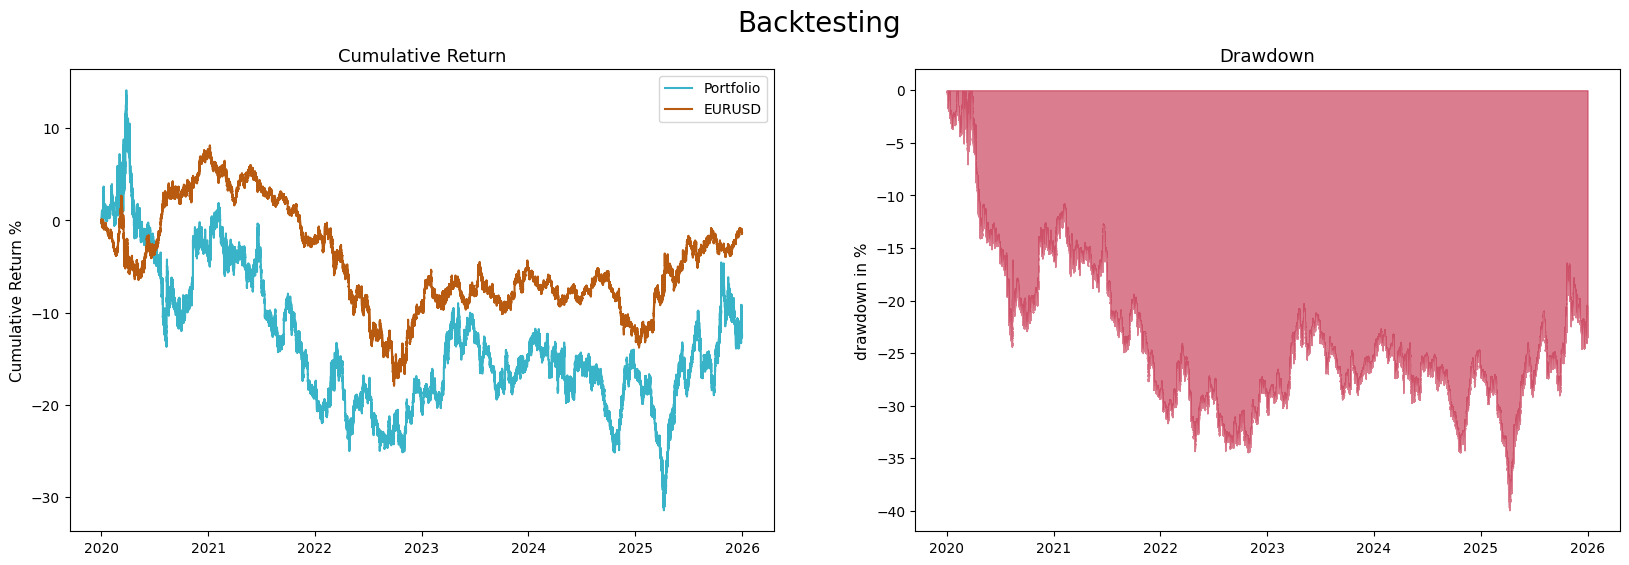

Final Return Portfolio: -12.49%
Final Return EURUSD: -1.29%
Sortino: -0.084
Beta: 0.0
Alpha: -1.014 %
MaxDrawdown: 39.949 %


In [10]:
dfc = DonchianChannel_strategy(df_GOLD, transaction_cost=0.00001)
metrics = BackTest(dfc, df_baseline, selected_timeframe)

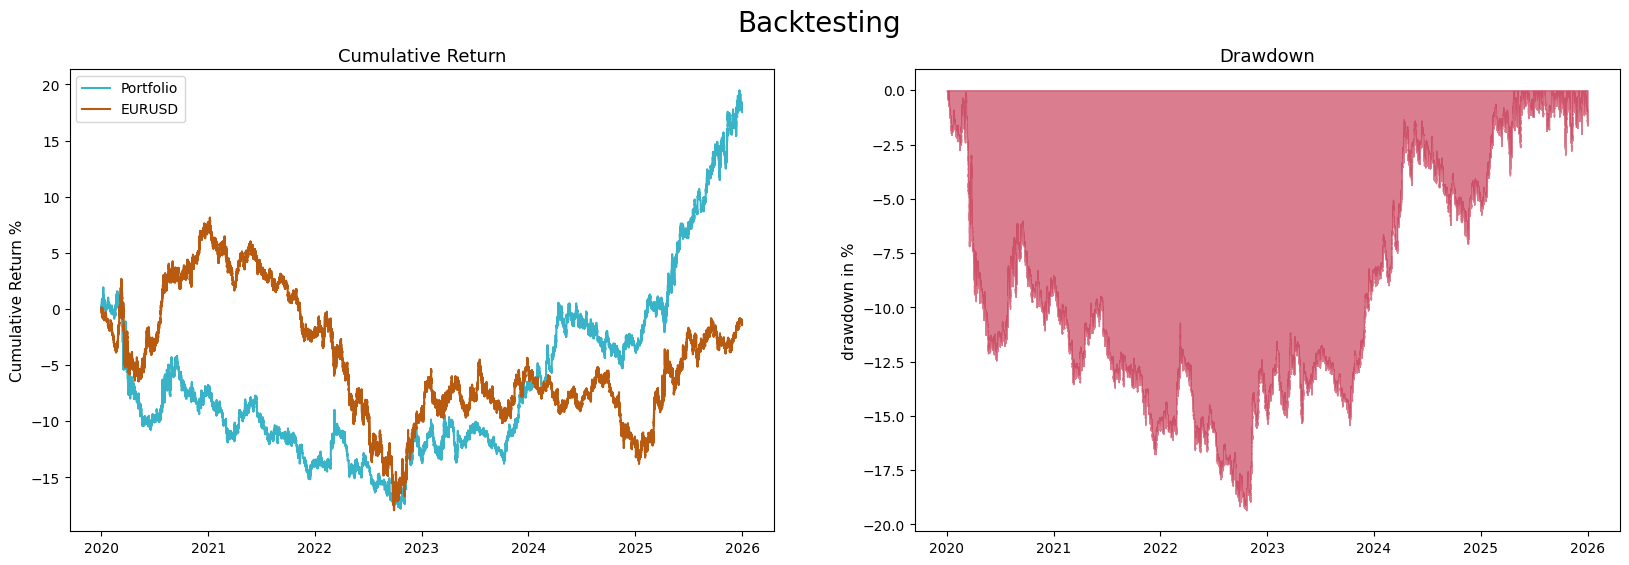

Final Return Portfolio: 17.53%
Final Return EURUSD: -1.29%
Sortino: 0.259
Beta: -0.001
Alpha: 3.084 %
MaxDrawdown: 19.353 %


In [11]:
dfc_v2 = DonchianChannel_strategy_v2(
    df_GOLD,
    lower_length=20,
    upper_length=55,
    trend_length=200,
    exit_ema_length=50,
    atr_length=14,
    atr_stop_mult=2.0,
    atr_trail_mult=3.0,
    transaction_cost=0.00001,
    long_only=True,
    breakout_buffer=0.0,
)
metrics_v2 = BackTest(dfc_v2, df_baseline, selected_timeframe)

Starting expanded v2 optimization...
Testing 288 combinations

✓ [  1] L/U=20/55, T/E=150/30, buf=0.0000, stop/trail=1.5/2.5 | Return:   2.54%
✓ [  2] L/U=20/55, T/E=150/30, buf=0.0000, stop/trail=1.5/3.0 | Return:  14.79%
✓ [  3] L/U=20/55, T/E=150/30, buf=0.0000, stop/trail=2.0/2.5 | Return:   4.03%
✓ [  4] L/U=20/55, T/E=150/30, buf=0.0000, stop/trail=2.0/3.0 | Return:  17.72%
✓ [  5] L/U=20/55, T/E=150/30, buf=0.0002, stop/trail=1.5/2.5 | Return:  -2.80%
✓ [  6] L/U=20/55, T/E=150/30, buf=0.0002, stop/trail=1.5/3.0 | Return:   3.19%
✓ [  7] L/U=20/55, T/E=150/30, buf=0.0002, stop/trail=2.0/2.5 | Return:   4.08%
✓ [  8] L/U=20/55, T/E=150/30, buf=0.0002, stop/trail=2.0/3.0 | Return:   9.62%
✓ [  9] L/U=20/55, T/E=150/50, buf=0.0000, stop/trail=1.5/2.5 | Return:   5.88%
✓ [ 10] L/U=20/55, T/E=150/50, buf=0.0000, stop/trail=1.5/3.0 | Return:  22.09%
✓ [ 11] L/U=20/55, T/E=150/50, buf=0.0000, stop/trail=2.0/2.5 | Return:   8.90%
✓ [ 12] L/U=20/55, T/E=150/50, buf=0.0000, stop/trail=2.0

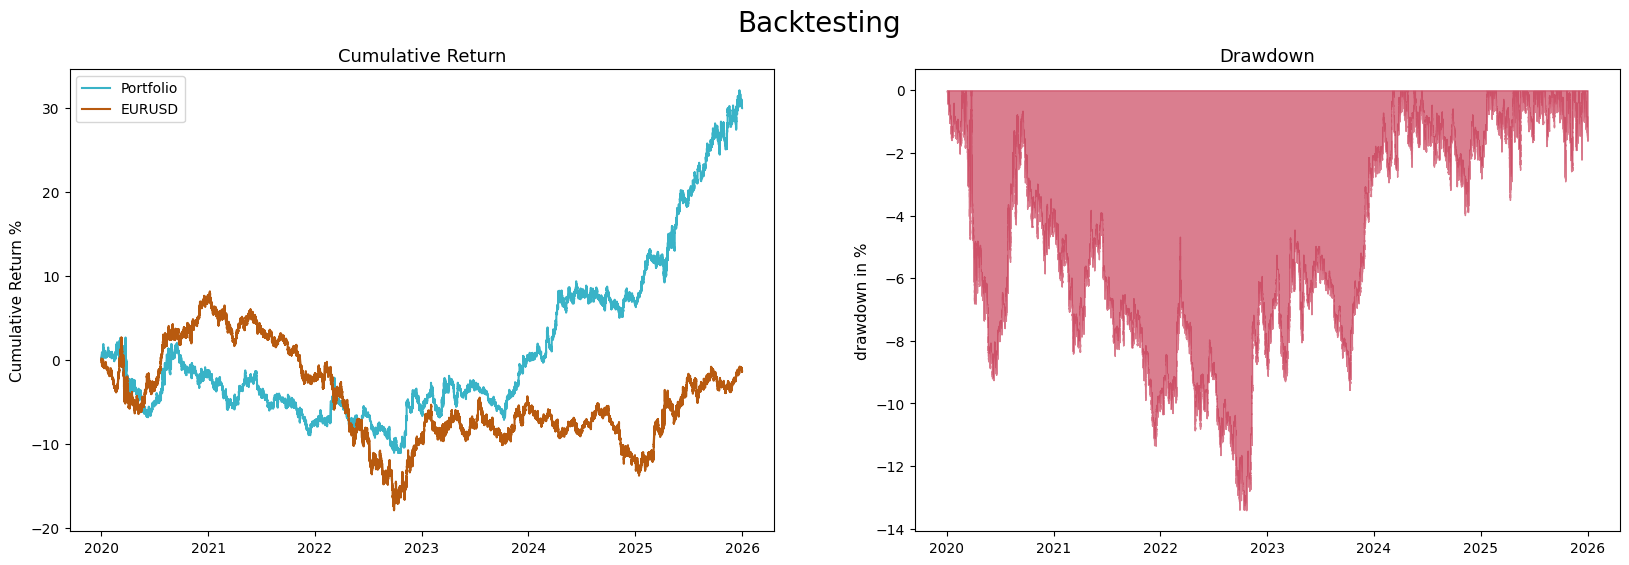

Final Return Portfolio: 29.98%
Final Return EURUSD: -1.29%
Sortino: 0.409
Beta: -0.0
Alpha: 4.831 %
MaxDrawdown: 13.412 %


In [12]:
# Expanded parameter optimization loop for DonchianChannel_strategy_v2
import io
from contextlib import redirect_stdout
from itertools import product

lower_lengths = [20, 30, 40]
upper_lengths = [55, 65, 75]
trend_lengths = [150, 200]
exit_ema_lengths = [30, 50]
breakout_buffers = [0.0, 0.0002]
atr_stop_mults = [1.5, 2.0]
atr_trail_mults = [2.5, 3.0]

atr_length = 14
transaction_cost = 0.00001
long_only = True

optimization_results = []

param_grid = list(
    product(
        lower_lengths,
        upper_lengths,
        trend_lengths,
        exit_ema_lengths,
        breakout_buffers,
        atr_stop_mults,
        atr_trail_mults,
    )
)

print("Starting expanded v2 optimization...")
print(f"Testing {len(param_grid)} combinations\n")

for count, (
    lower_len,
    upper_len,
    trend_len,
    exit_ema_len,
    breakout_buf,
    atr_stop,
    atr_trail,
) in enumerate(param_grid, start=1):

    if upper_len <= lower_len:
        print(f"- [{count:3d}] lower={lower_len:2d}, upper={upper_len:2d} | Skipped (upper must be > lower)")
        continue

    if atr_trail <= atr_stop:
        print(f"- [{count:3d}] atr_stop={atr_stop:.1f}, atr_trail={atr_trail:.1f} | Skipped (trail must be > stop)")
        continue

    try:
        dfc_opt = DonchianChannel_strategy_v2(
            df_GOLD,
            lower_length=lower_len,
            upper_length=upper_len,
            trend_length=trend_len,
            exit_ema_length=exit_ema_len,
            atr_length=atr_length,
            atr_stop_mult=atr_stop,
            atr_trail_mult=atr_trail,
            transaction_cost=transaction_cost,
            long_only=long_only,
            breakout_buffer=breakout_buf,
        )

        with redirect_stdout(io.StringIO()):
            metrics_opt = BackTest(dfc_opt, df_baseline, selected_timeframe, plot=False)

        if metrics_opt is not None:
            optimization_results.append({
                "lower_length": lower_len,
                "upper_length": upper_len,
                "trend_length": trend_len,
                "exit_ema_length": exit_ema_len,
                "breakout_buffer": breakout_buf,
                "atr_stop_mult": atr_stop,
                "atr_trail_mult": atr_trail,
                "final_return_portfolio": metrics_opt["final_return_portfolio"],
                "final_return_benchmark": metrics_opt["final_return_benchmark"],
                "sortino": metrics_opt["sortino"],
                "beta": metrics_opt["beta"],
                "alpha": metrics_opt["alpha"],
                "max_drawdown": metrics_opt["max_drawdown"],
            })
            print(
                f"✓ [{count:3d}] L/U={lower_len}/{upper_len}, T/E={trend_len}/{exit_ema_len}, "
                f"buf={breakout_buf:.4f}, stop/trail={atr_stop:.1f}/{atr_trail:.1f} "
                f"| Return: {metrics_opt['final_return_portfolio']:7.2%}"
            )

    except Exception as e:
        print(f"✗ [{count:3d}] Error: {str(e)[:70]}")

print(f"\n✓ Completed {len(param_grid)} combinations, {len(optimization_results)} successful\n")

if not optimization_results:
    print("WARNING: No valid parameter combinations found!")
else:
    results_df = pd.DataFrame(optimization_results)
    results_df = results_df.sort_values("final_return_portfolio", ascending=False)

    print("=" * 120)
    print("TOP 15 V2 PARAMETER COMBINATIONS (sorted by Final Return)")
    print("=" * 120)
    display_cols = [
        "lower_length",
        "upper_length",
        "trend_length",
        "exit_ema_length",
        "breakout_buffer",
        "atr_stop_mult",
        "atr_trail_mult",
        "final_return_portfolio",
        "sortino",
        "alpha",
        "max_drawdown",
    ]
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)
    pd.set_option("display.float_format", "{:.4f}".format)
    print(results_df[display_cols].head(15).to_string())

    best_row = results_df.iloc[0]
    print(f"\n{'=' * 120}")
    print("BEST V2 PARAMETERS:")
    print(f"  Lower Length: {int(best_row['lower_length'])}")
    print(f"  Upper Length: {int(best_row['upper_length'])}")
    print(f"  Trend Length: {int(best_row['trend_length'])}")
    print(f"  Exit EMA Length: {int(best_row['exit_ema_length'])}")
    print(f"  Breakout Buffer: {best_row['breakout_buffer']:.4f}")
    print(f"  ATR Stop Mult: {best_row['atr_stop_mult']:.2f}")
    print(f"  ATR Trail Mult: {best_row['atr_trail_mult']:.2f}")
    print(f"  Final Return: {best_row['final_return_portfolio']:.2%}")
    print(f"  Sortino Ratio: {best_row['sortino']:.3f}")
    print(f"  Alpha: {best_row['alpha']:.3%}")
    print(f"  Max Drawdown: {best_row['max_drawdown']:.3f}%")
    print(f"{'=' * 120}\n")

    print("Running final v2 backtest with best parameters...\n")
    dfc_best = DonchianChannel_strategy_v2(
        df_GOLD,
        lower_length=int(best_row['lower_length']),
        upper_length=int(best_row['upper_length']),
        trend_length=int(best_row['trend_length']),
        exit_ema_length=int(best_row['exit_ema_length']),
        atr_length=atr_length,
        atr_stop_mult=float(best_row['atr_stop_mult']),
        atr_trail_mult=float(best_row['atr_trail_mult']),
        transaction_cost=transaction_cost,
        long_only=long_only,
        breakout_buffer=float(best_row['breakout_buffer']),
    )
    metrics_best = BackTest(dfc_best, df_baseline, selected_timeframe)

In [13]:
def SMA_strategy(df=df_GOLD_Raw, transaction_cost=0.0):
  
    df = df.copy()

    # Calculate Donchian channels and drop rows with NaN values 
    df[["dcl", "dcm", "dcu"]] = df.ta.donchian(lower_length=40, upper_length=50)
    df = df.dropna().drop(columns=["time", "dateTime"], errors="ignore")

    df["position"] = np.nan

    # Create the condition
    # Entry: exact touch of Donchian upper band
    df.loc[(df["high"] == df["dcu"]), "position"] = 1
    # Exit: exact touch of Donchian lower band
    df.loc[(df["low"] == df["dcl"]), "position"] = -1

    # Keep previous position between signals, then flat before first signal
    df["position"] = df["position"].ffill().fillna(0)

    df["pct"] = df["close"].pct_change(1)

    # Apply transaction cost only when a position change occurs
    turnover = df["position"].diff().abs().fillna(0).clip(upper=1)
    df["return"] = df["pct"] * df["position"].shift(1) - transaction_cost * turnover

    # Keep only valid strategy returns; avoids plotting an all-NaN series
    ret = df["return"].dropna()
    if ret.empty:
        raise ValueError("No valid returns. Download more history or reduce SMA windows.")

    return ret

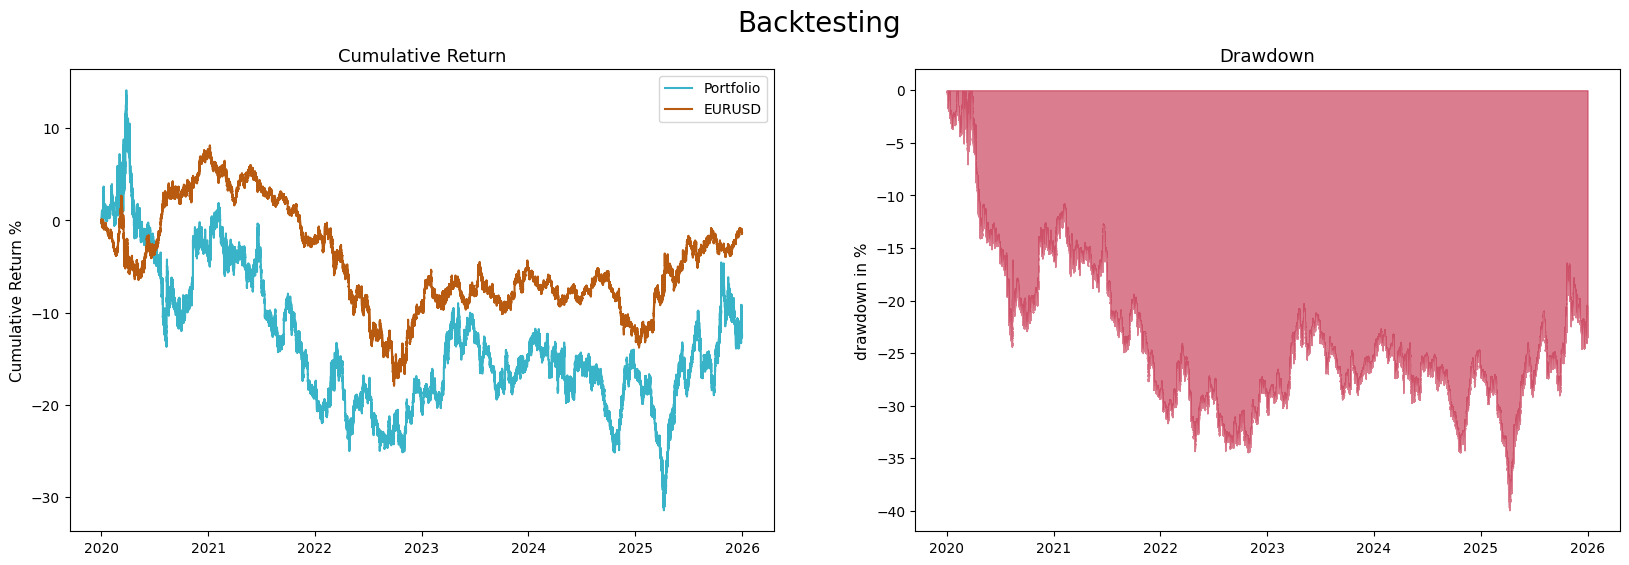

Final Return Portfolio: -12.49%
Final Return EURUSD: -1.29%
Sortino: -0.084
Beta: 0.0
Alpha: -1.014 %
MaxDrawdown: 39.949 %


In [14]:
df_GOLD = get_resampled(df_GOLD_Raw, high_freq="5min")
dfc = SMA_strategy(df_GOLD, transaction_cost=0.00001)
metrics = BackTest(dfc, df_baseline, selected_timeframe)

In [15]:
# Summary of optimization results
print("\n" + "="*100)
print("OPTIMIZATION SUMMARY")
print("="*100)

if 'results_df' in locals():
    print(f"\nTotal combinations tested: {len(results_df)}")
    print(f"\nParameter ranges:")
    print(f"  Lower Length: {results_df['lower_length'].min():.0f} - {results_df['lower_length'].max():.0f}")
    print(f"  Upper Length: {results_df['upper_length'].min():.0f} - {results_df['upper_length'].max():.0f}")
    
    # Best by return
    best_return_idx = results_df['final_return_portfolio'].idxmax()
    best_return_row = results_df.loc[best_return_idx]
    print(f"\n{'BEST by Final Return:':-^100}")
    print(f"  Parameters: lower={int(best_return_row['lower_length'])}, upper={int(best_return_row['upper_length'])}")
    print(f"  Final Return: {best_return_row['final_return_portfolio']:.2%}")
    print(f"  Sortino: {best_return_row['sortino']:.3f}")
    print(f"  Alpha: {best_return_row['alpha']:.3%}")
    
    # Best by Sortino
    best_sortino_idx = results_df['sortino'].idxmax()
    best_sortino_row = results_df.loc[best_sortino_idx]
    print(f"\n{'BEST by Sortino Ratio:':-^100}")
    print(f"  Parameters: lower={int(best_sortino_row['lower_length'])}, upper={int(best_sortino_row['upper_length'])}")
    print(f"  Sortino: {best_sortino_row['sortino']:.3f}")
    print(f"  Final Return: {best_sortino_row['final_return_portfolio']:.2%}")
    print(f"  Alpha: {best_sortino_row['alpha']:.3%}")
    
    # Best by Alpha
    best_alpha_idx = results_df['alpha'].idxmax()
    best_alpha_row = results_df.loc[best_alpha_idx]
    print(f"\n{'BEST by Alpha:':-^100}")
    print(f"  Parameters: lower={int(best_alpha_row['lower_length'])}, upper={int(best_alpha_row['upper_length'])}")
    print(f"  Alpha: {best_alpha_row['alpha']:.3%}")
    print(f"  Final Return: {best_alpha_row['final_return_portfolio']:.2%}")
    print(f"  Sortino: {best_alpha_row['sortino']:.3f}")
    
    # Statistics
    print(f"\n{'Overall Statistics:':-^100}")
    print(f"  Avg Return: {results_df['final_return_portfolio'].mean():.2%}")
    print(f"  Best Return: {results_df['final_return_portfolio'].max():.2%}")
    print(f"  Worst Return: {results_df['final_return_portfolio'].min():.2%}")
    print(f"  Median Return: {results_df['final_return_portfolio'].median():.2%}")
    
    print("\n" + "="*100)
else:
    print("Results dataframe not available. Run the optimization cell first.")


OPTIMIZATION SUMMARY

Total combinations tested: 288

Parameter ranges:
  Lower Length: 20 - 40
  Upper Length: 55 - 75

---------------------------------------BEST by Final Return:----------------------------------------
  Parameters: lower=30, upper=65
  Final Return: 29.98%
  Sortino: 0.409
  Alpha: 4.831%

---------------------------------------BEST by Sortino Ratio:---------------------------------------
  Parameters: lower=30, upper=65
  Sortino: 0.409
  Final Return: 29.98%
  Alpha: 4.831%

-------------------------------------------BEST by Alpha:-------------------------------------------
  Parameters: lower=30, upper=65
  Alpha: 4.831%
  Final Return: 29.98%
  Sortino: 0.409

----------------------------------------Overall Statistics:-----------------------------------------
  Avg Return: 7.96%
  Best Return: 29.98%
  Worst Return: -6.63%
  Median Return: 6.95%



In [16]:
best = results_df.iloc[0]
print("Best expanded-v2 parameters:")
print(best[[
    "lower_length",
    "upper_length",
    "trend_length",
    "exit_ema_length",
    "breakout_buffer",
    "atr_stop_mult",
    "atr_trail_mult",
    "final_return_portfolio",
    "sortino",
    "alpha",
    "max_drawdown",
]])

Best expanded-v2 parameters:
lower_length              30.0000
upper_length              65.0000
trend_length             150.0000
exit_ema_length           50.0000
breakout_buffer            0.0000
atr_stop_mult              2.0000
atr_trail_mult             3.0000
final_return_portfolio     0.2998
sortino                    0.4093
alpha                      0.0483
max_drawdown              13.4115
Name: 139, dtype: float64


Starting focused refinement optimization...
Testing 96 combinations

Processed 12/96 combinations
Processed 24/96 combinations
Processed 36/96 combinations
Processed 48/96 combinations
Processed 60/96 combinations
Processed 72/96 combinations
Processed 84/96 combinations
Processed 96/96 combinations

TOP 10 FOCUSED REFINEMENT RESULTS
 final_return_portfolio  sortino  max_drawdown  alpha  breakout_buffer  atr_stop_mult  atr_trail_mult  entry_confirm_bars  cooldown_bars  use_midline_exit
                 0.2998   0.4093       13.4115 0.0483           0.0000         2.0000          3.0000                   1              0             False
                 0.2990   0.4126       14.3504 0.0481           0.0000         2.0000          3.0000                   1              2             False
                 0.2768   0.3873       14.6278 0.0451           0.0000         1.8000          3.0000                   1              2             False
                 0.2723   0.3802       13.29

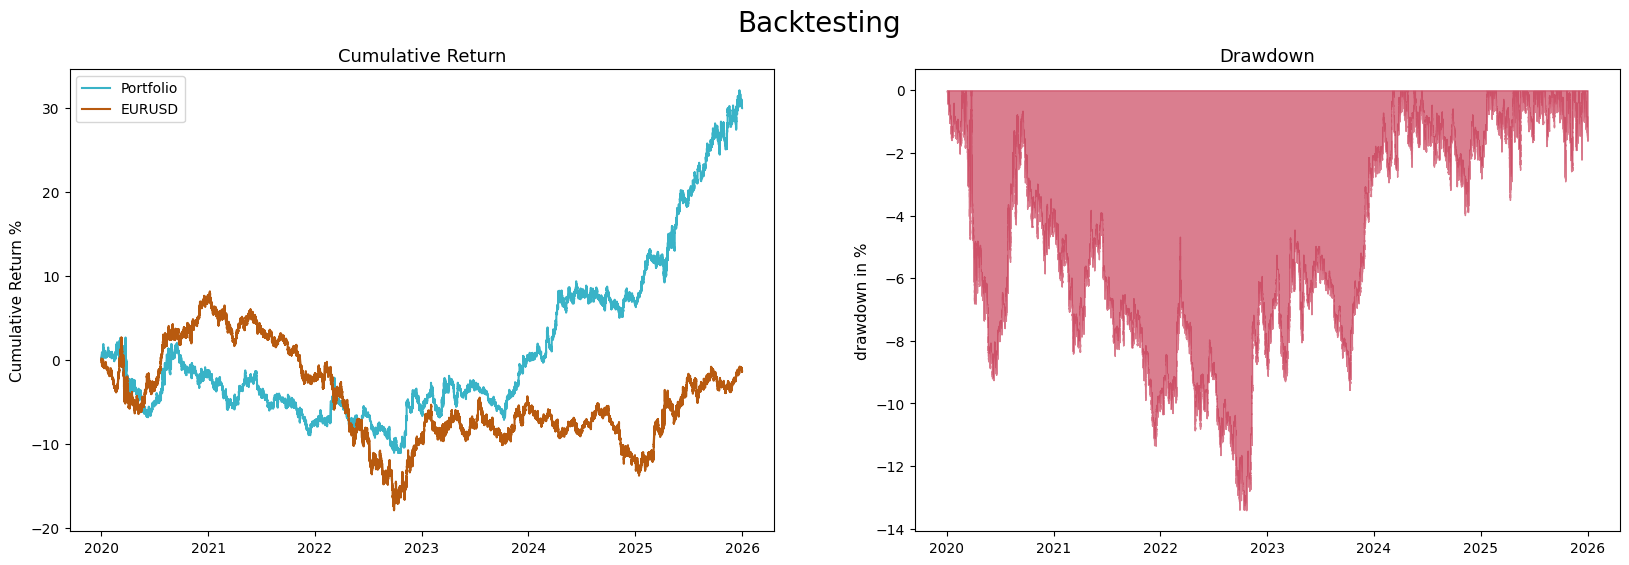

Final Return Portfolio: 29.98%
Final Return EURUSD: -1.29%
Sortino: 0.409
Beta: -0.0
Alpha: 4.831 %
MaxDrawdown: 13.412 %


In [17]:
# Focused refinement around best expanded-v2 core settings
import io
from contextlib import redirect_stdout
from itertools import product

ref_lower_lengths = [30]
ref_upper_lengths = [65]
ref_trend_lengths = [150]
ref_exit_ema_lengths = [50]

ref_breakout_buffers = [0.0, 0.0001]
ref_atr_stop_mults = [1.8, 2.0]
ref_atr_trail_mults = [2.8, 3.0]
ref_entry_confirm_bars = [1, 2]
ref_cooldown_bars = [0, 2, 4]
ref_use_midline_exit = [False, True]

ref_atr_length = 14
ref_transaction_cost = 0.00001
ref_long_only = True

ref_results = []

ref_param_grid = list(
    product(
        ref_lower_lengths,
        ref_upper_lengths,
        ref_trend_lengths,
        ref_exit_ema_lengths,
        ref_breakout_buffers,
        ref_atr_stop_mults,
        ref_atr_trail_mults,
        ref_entry_confirm_bars,
        ref_cooldown_bars,
        ref_use_midline_exit,
    )
)

print("Starting focused refinement optimization...")
print(f"Testing {len(ref_param_grid)} combinations\n")

for idx, (
    lower_len,
    upper_len,
    trend_len,
    exit_ema_len,
    breakout_buf,
    atr_stop,
    atr_trail,
    entry_confirm,
    cooldown,
    midline_exit,
) in enumerate(ref_param_grid, start=1):
    if atr_trail <= atr_stop:
        continue

    try:
        dfc_ref = DonchianChannel_strategy_v2(
            df_GOLD,
            lower_length=lower_len,
            upper_length=upper_len,
            trend_length=trend_len,
            exit_ema_length=exit_ema_len,
            atr_length=ref_atr_length,
            atr_stop_mult=atr_stop,
            atr_trail_mult=atr_trail,
            entry_confirm_bars=entry_confirm,
            cooldown_bars=cooldown,
            use_midline_exit=midline_exit,
            transaction_cost=ref_transaction_cost,
            long_only=ref_long_only,
            breakout_buffer=breakout_buf,
        )

        with redirect_stdout(io.StringIO()):
            m_ref = BackTest(dfc_ref, df_baseline, selected_timeframe, plot=False)

        ref_results.append({
            "lower_length": lower_len,
            "upper_length": upper_len,
            "trend_length": trend_len,
            "exit_ema_length": exit_ema_len,
            "breakout_buffer": breakout_buf,
            "atr_stop_mult": atr_stop,
            "atr_trail_mult": atr_trail,
            "entry_confirm_bars": entry_confirm,
            "cooldown_bars": cooldown,
            "use_midline_exit": midline_exit,
            "final_return_portfolio": m_ref["final_return_portfolio"],
            "sortino": m_ref["sortino"],
            "alpha": m_ref["alpha"],
            "max_drawdown": m_ref["max_drawdown"],
        })

        if idx % 12 == 0:
            print(f"Processed {idx}/{len(ref_param_grid)} combinations")

    except Exception:
        continue

if not ref_results:
    print("No valid combinations in refinement run.")
else:
    ref_results_df = pd.DataFrame(ref_results).sort_values("final_return_portfolio", ascending=False)

    print("\n" + "=" * 120)
    print("TOP 10 FOCUSED REFINEMENT RESULTS")
    print("=" * 120)
    cols = [
        "final_return_portfolio",
        "sortino",
        "max_drawdown",
        "alpha",
        "breakout_buffer",
        "atr_stop_mult",
        "atr_trail_mult",
        "entry_confirm_bars",
        "cooldown_bars",
        "use_midline_exit",
    ]
    print(ref_results_df[cols].head(10).to_string(index=False))

    ref_best = ref_results_df.iloc[0]
    print("\nBest focused-refinement parameters:")
    print(ref_best[[
        "lower_length",
        "upper_length",
        "trend_length",
        "exit_ema_length",
        "breakout_buffer",
        "atr_stop_mult",
        "atr_trail_mult",
        "entry_confirm_bars",
        "cooldown_bars",
        "use_midline_exit",
        "final_return_portfolio",
        "sortino",
        "alpha",
        "max_drawdown",
    ]])

    print("\nRunning final backtest for refined best...\n")
    dfc_ref_best = DonchianChannel_strategy_v2(
        df_GOLD,
        lower_length=int(ref_best["lower_length"]),
        upper_length=int(ref_best["upper_length"]),
        trend_length=int(ref_best["trend_length"]),
        exit_ema_length=int(ref_best["exit_ema_length"]),
        atr_length=ref_atr_length,
        atr_stop_mult=float(ref_best["atr_stop_mult"]),
        atr_trail_mult=float(ref_best["atr_trail_mult"]),
        entry_confirm_bars=int(ref_best["entry_confirm_bars"]),
        cooldown_bars=int(ref_best["cooldown_bars"]),
        use_midline_exit=bool(ref_best["use_midline_exit"]),
        transaction_cost=ref_transaction_cost,
        long_only=ref_long_only,
        breakout_buffer=float(ref_best["breakout_buffer"]),
    )
    metrics_ref_best = BackTest(dfc_ref_best, df_baseline, selected_timeframe)

In [18]:
if 'ref_results_df' in locals() and not ref_results_df.empty:
    print(ref_results_df.head(1).to_string(index=False))
else:
    print('ref_results_df not available')

 lower_length  upper_length  trend_length  exit_ema_length  breakout_buffer  atr_stop_mult  atr_trail_mult  entry_confirm_bars  cooldown_bars  use_midline_exit  final_return_portfolio  sortino  alpha  max_drawdown
           30            65           150               50           0.0000         2.0000          3.0000                   1              0             False                  0.2998   0.4093 0.0483       13.4115


Walk-forward starting with 1152 candidate params per fold...
Fold 1: train=-4.12%, test=4.09%, params L/U=25/65
Fold 2: train=4.44%, test=8.00%, params L/U=35/60
Fold 3: train=6.46%, test=12.31%, params L/U=35/60
Fold 4: train=13.92%, test=15.84%, params L/U=35/65

WALK-FORWARD SUMMARY
Folds evaluated: 4
Mean train return: 5.18%
Mean test return: 10.06%
Median test return: 10.15%
Positive test folds: 4/4
Mean test max drawdown: 4.45%

Top 5 folds by test return:
 fold  train_return  test_return  test_sortino  test_max_drawdown  lower_length  upper_length  trend_length  exit_ema_length  atr_stop_mult  atr_trail_mult  entry_confirm_bars  cooldown_bars
    4        0.1392       0.1584        1.1013             4.1012            35            65           150               40         2.0000          2.8000                   1              0
    3        0.0646       0.1231        0.9235             4.8416            35            60           150               50         1.8000          2.

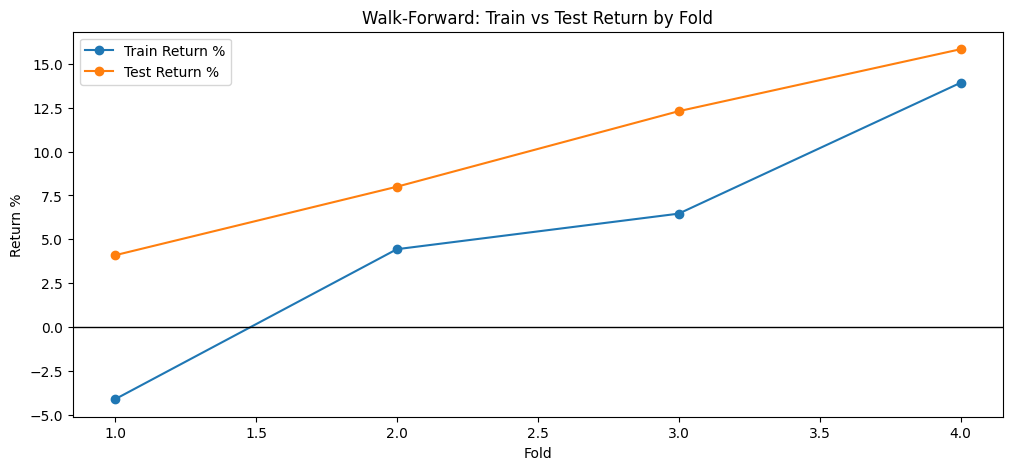

In [19]:
# Walk-forward validation (optimize on train, evaluate on next test window)
import io
from contextlib import redirect_stdout
from itertools import product

# Compact candidate set around current best (to keep runtime practical)
wf_candidates = {
    "lower_length": [25, 30, 35],
    "upper_length": [60, 65, 70],
    "trend_length": [150, 200],
    "exit_ema_length": [40, 50],
    "breakout_buffer": [0.0, 0.0001],
    "atr_stop_mult": [1.8, 2.0],
    "atr_trail_mult": [2.8, 3.0],
    "entry_confirm_bars": [1, 2],
    "cooldown_bars": [0, 2],
    "use_midline_exit": [False],
}

wf_fixed = {
    "atr_length": 14,
    "transaction_cost": 0.00001,
    "long_only": True,
}

# 70% train, 20% test, 10% step overlap-like progression via rolling anchor
n = len(df_GOLD)
train_size = int(n * 0.50)
test_size = int(n * 0.20)
step_size = int(n * 0.10)

if train_size < 1000 or test_size < 500:
    raise ValueError("Not enough data for walk-forward split sizes.")

param_grid = list(product(
    wf_candidates["lower_length"],
    wf_candidates["upper_length"],
    wf_candidates["trend_length"],
    wf_candidates["exit_ema_length"],
    wf_candidates["breakout_buffer"],
    wf_candidates["atr_stop_mult"],
    wf_candidates["atr_trail_mult"],
    wf_candidates["entry_confirm_bars"],
    wf_candidates["cooldown_bars"],
    wf_candidates["use_midline_exit"],
))

fold_results = []
start = 0
fold = 0

print(f"Walk-forward starting with {len(param_grid)} candidate params per fold...")

while (start + train_size + test_size) <= n:
    fold += 1
    train_slice = df_GOLD.iloc[start:start + train_size]
    test_slice = df_GOLD.iloc[start + train_size:start + train_size + test_size]

    best_train_score = -np.inf
    best_params = None
    best_train_metrics = None

    for (
        lower_length,
        upper_length,
        trend_length,
        exit_ema_length,
        breakout_buffer,
        atr_stop_mult,
        atr_trail_mult,
        entry_confirm_bars,
        cooldown_bars,
        use_midline_exit,
    ) in param_grid:

        if upper_length <= lower_length or atr_trail_mult <= atr_stop_mult:
            continue

        try:
            train_ret = DonchianChannel_strategy_v2(
                train_slice,
                lower_length=lower_length,
                upper_length=upper_length,
                trend_length=trend_length,
                exit_ema_length=exit_ema_length,
                atr_length=wf_fixed["atr_length"],
                atr_stop_mult=atr_stop_mult,
                atr_trail_mult=atr_trail_mult,
                entry_confirm_bars=entry_confirm_bars,
                cooldown_bars=cooldown_bars,
                use_midline_exit=use_midline_exit,
                transaction_cost=wf_fixed["transaction_cost"],
                long_only=wf_fixed["long_only"],
                breakout_buffer=breakout_buffer,
            )
            with redirect_stdout(io.StringIO()):
                train_metrics = BackTest(train_ret, df_baseline, selected_timeframe, plot=False)

            # Objective: maximize return with mild drawdown penalty
            score = train_metrics["final_return_portfolio"] - 0.002 * train_metrics["max_drawdown"]
            if score > best_train_score:
                best_train_score = score
                best_params = {
                    "lower_length": lower_length,
                    "upper_length": upper_length,
                    "trend_length": trend_length,
                    "exit_ema_length": exit_ema_length,
                    "breakout_buffer": breakout_buffer,
                    "atr_stop_mult": atr_stop_mult,
                    "atr_trail_mult": atr_trail_mult,
                    "entry_confirm_bars": entry_confirm_bars,
                    "cooldown_bars": cooldown_bars,
                    "use_midline_exit": use_midline_exit,
                }
                best_train_metrics = train_metrics
        except Exception:
            continue

    if best_params is None:
        print(f"Fold {fold}: no valid parameter set")
        start += step_size
        continue

    # Evaluate best-train params on forward test window
    test_ret = DonchianChannel_strategy_v2(
        test_slice,
        lower_length=best_params["lower_length"],
        upper_length=best_params["upper_length"],
        trend_length=best_params["trend_length"],
        exit_ema_length=best_params["exit_ema_length"],
        atr_length=wf_fixed["atr_length"],
        atr_stop_mult=best_params["atr_stop_mult"],
        atr_trail_mult=best_params["atr_trail_mult"],
        entry_confirm_bars=best_params["entry_confirm_bars"],
        cooldown_bars=best_params["cooldown_bars"],
        use_midline_exit=best_params["use_midline_exit"],
        transaction_cost=wf_fixed["transaction_cost"],
        long_only=wf_fixed["long_only"],
        breakout_buffer=best_params["breakout_buffer"],
    )
    with redirect_stdout(io.StringIO()):
        test_metrics = BackTest(test_ret, df_baseline, selected_timeframe, plot=False)

    fold_results.append({
        "fold": fold,
        "train_start": train_slice.index[0],
        "train_end": train_slice.index[-1],
        "test_start": test_slice.index[0],
        "test_end": test_slice.index[-1],
        "train_return": best_train_metrics["final_return_portfolio"],
        "test_return": test_metrics["final_return_portfolio"],
        "train_sortino": best_train_metrics["sortino"],
        "test_sortino": test_metrics["sortino"],
        "test_max_drawdown": test_metrics["max_drawdown"],
        **best_params,
    })

    print(
        f"Fold {fold}: train={best_train_metrics['final_return_portfolio']:.2%}, "
        f"test={test_metrics['final_return_portfolio']:.2%}, "
        f"params L/U={best_params['lower_length']}/{best_params['upper_length']}"
    )

    start += step_size

wf_results_df = pd.DataFrame(fold_results)

print("\n" + "=" * 110)
print("WALK-FORWARD SUMMARY")
print("=" * 110)
print(f"Folds evaluated: {len(wf_results_df)}")
print(f"Mean train return: {wf_results_df['train_return'].mean():.2%}")
print(f"Mean test return: {wf_results_df['test_return'].mean():.2%}")
print(f"Median test return: {wf_results_df['test_return'].median():.2%}")
print(f"Positive test folds: {(wf_results_df['test_return'] > 0).sum()}/{len(wf_results_df)}")
print(f"Mean test max drawdown: {wf_results_df['test_max_drawdown'].mean():.2f}%")

print("\nTop 5 folds by test return:")
print(wf_results_df.sort_values('test_return', ascending=False).head(5)[[
    'fold', 'train_return', 'test_return', 'test_sortino', 'test_max_drawdown',
    'lower_length', 'upper_length', 'trend_length', 'exit_ema_length',
    'atr_stop_mult', 'atr_trail_mult', 'entry_confirm_bars', 'cooldown_bars'
]].to_string(index=False))

# Simple visual check of generalization per fold
plt.figure(figsize=(12, 5))
plt.plot(wf_results_df['fold'], wf_results_df['train_return'] * 100, marker='o', label='Train Return %')
plt.plot(wf_results_df['fold'], wf_results_df['test_return'] * 100, marker='o', label='Test Return %')
plt.axhline(0, color='black', linewidth=1)
plt.title('Walk-Forward: Train vs Test Return by Fold')
plt.xlabel('Fold')
plt.ylabel('Return %')
plt.legend()
plt.show()

Rolling live-style segment summary:
 fold       segment_start         segment_end  bars  segment_return  lower_length  upper_length  trend_length  exit_ema_length
    1 2022-11-23 17:15:00 2023-07-07 09:55:00 44086          0.0201            25            65           200               40
    2 2023-07-07 10:00:00 2024-02-20 19:50:00 44086          0.0162            35            60           150               50
    3 2024-02-20 19:55:00 2024-10-03 04:45:00 44086          0.0553            35            60           150               50
    4 2024-10-03 04:50:00 2025-05-20 12:25:00 44086          0.0728            35            65           150               40

Running stitched out-of-sample backtest...



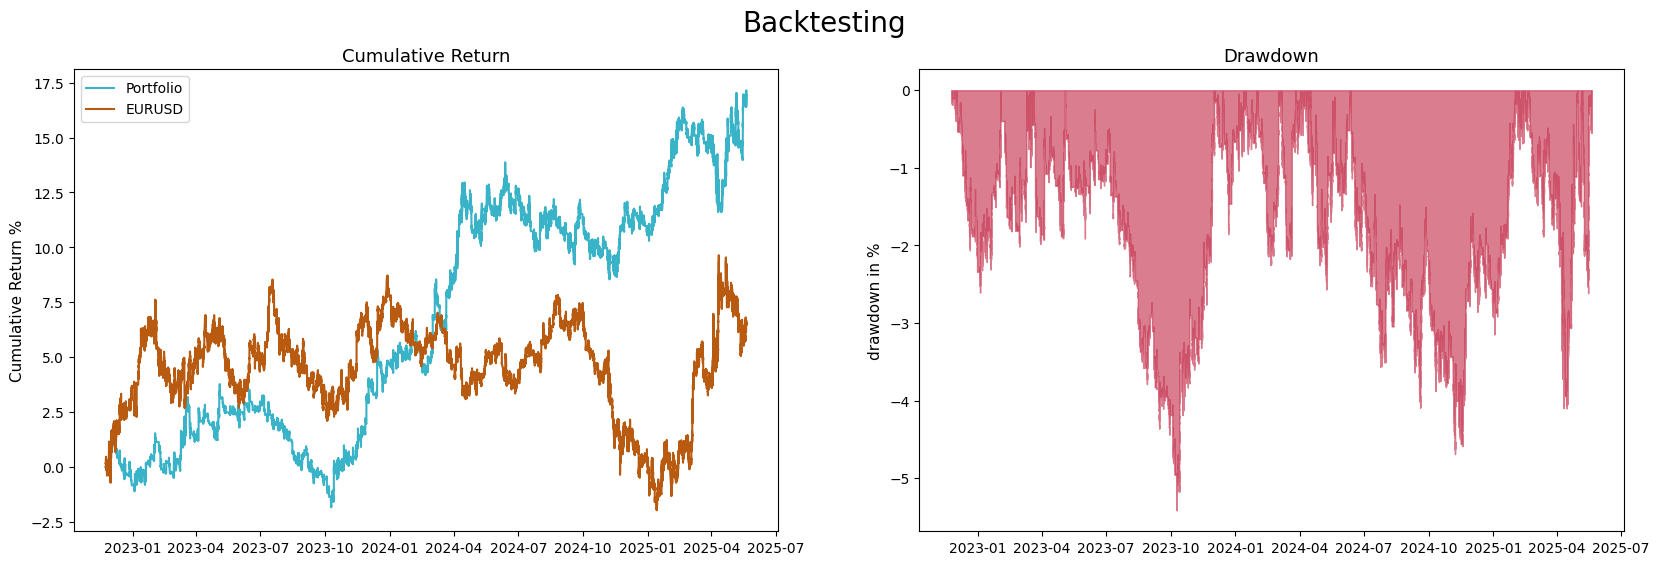

Final Return Portfolio: 16.94%
Final Return EURUSD: 6.53%
Sortino: 0.643
Beta: 0.002
Alpha: 6.771 %
MaxDrawdown: 5.414 %


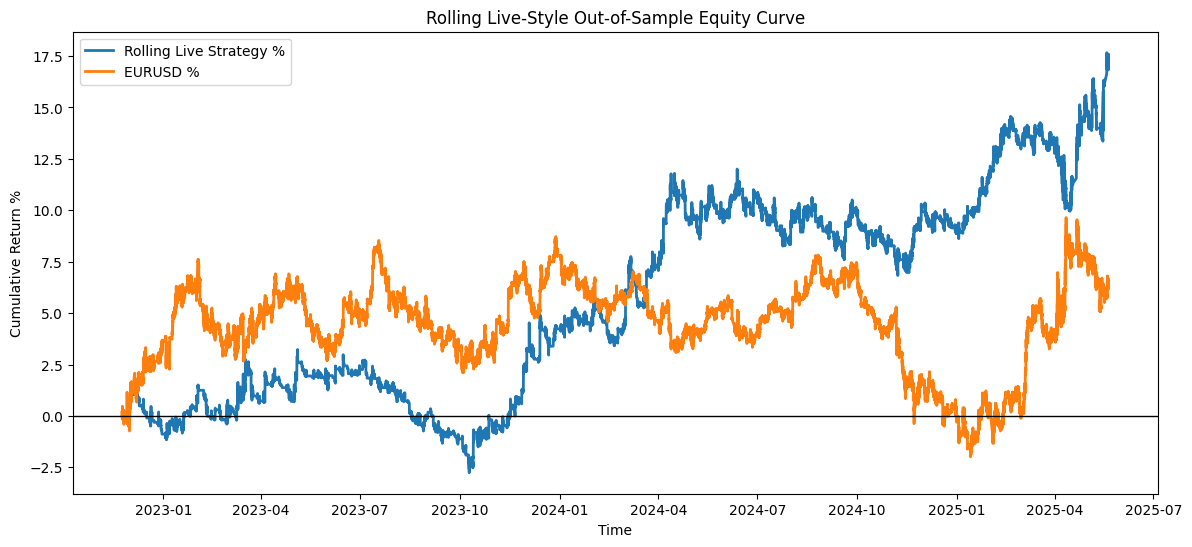


Live-style summary metrics:
Total stitched return: 17.37%
Segments traded: 4


In [20]:
# Rolling live-style simulation using frozen params from each walk-forward fold
if 'wf_results_df' not in locals() or wf_results_df.empty:
    raise ValueError('Run the walk-forward validation cell first.')

live_segments = []
live_segment_summary = []
start = 0

for _, row in wf_results_df.sort_values('fold').iterrows():
    live_start = start + train_size
    live_end = min(live_start + step_size, len(df_GOLD))

    if live_start >= len(df_GOLD):
        break

    live_slice = df_GOLD.iloc[live_start:live_end]
    if live_slice.empty:
        start += step_size
        continue

    live_ret = DonchianChannel_strategy_v2(
        live_slice,
        lower_length=int(row['lower_length']),
        upper_length=int(row['upper_length']),
        trend_length=int(row['trend_length']),
        exit_ema_length=int(row['exit_ema_length']),
        atr_length=wf_fixed['atr_length'],
        atr_stop_mult=float(row['atr_stop_mult']),
        atr_trail_mult=float(row['atr_trail_mult']),
        entry_confirm_bars=int(row['entry_confirm_bars']),
        cooldown_bars=int(row['cooldown_bars']),
        use_midline_exit=bool(row['use_midline_exit']),
        transaction_cost=wf_fixed['transaction_cost'],
        long_only=wf_fixed['long_only'],
        breakout_buffer=float(row['breakout_buffer']),
    )

    live_segments.append(live_ret.rename(f'fold_{int(row["fold"])}'))
    live_segment_summary.append({
        'fold': int(row['fold']),
        'segment_start': live_slice.index[0],
        'segment_end': live_slice.index[-1],
        'bars': len(live_slice),
        'segment_return': (1 + live_ret).prod() - 1,
        'lower_length': int(row['lower_length']),
        'upper_length': int(row['upper_length']),
        'trend_length': int(row['trend_length']),
        'exit_ema_length': int(row['exit_ema_length']),
    })

    start += step_size

if not live_segments:
    raise ValueError('No live segments were generated.')

live_returns = pd.concat(live_segments).sort_index()
live_returns = live_returns[~live_returns.index.duplicated(keep='first')]
live_summary_df = pd.DataFrame(live_segment_summary)

print('Rolling live-style segment summary:')
print(live_summary_df.to_string(index=False))

print('\nRunning stitched out-of-sample backtest...\n')
live_metrics = BackTest(live_returns, df_baseline, selected_timeframe)

live_equity = ((1 + live_returns).cumprod() - 1) * 100
baseline_live = df_baseline['close'].pct_change(1).rename('EURUSD')
aligned_live = pd.concat([live_returns.rename('strategy'), baseline_live], axis=1, join='inner').dropna()
benchmark_equity = ((1 + aligned_live['EURUSD']).cumprod() - 1) * 100

plt.figure(figsize=(14, 6))
plt.plot(live_equity.index, live_equity.values, label='Rolling Live Strategy %', linewidth=2)
plt.plot(benchmark_equity.index, benchmark_equity.values, label='EURUSD %', linewidth=2)
plt.axhline(0, color='black', linewidth=1)
plt.title('Rolling Live-Style Out-of-Sample Equity Curve')
plt.ylabel('Cumulative Return %')
plt.xlabel('Time')
plt.legend()
plt.show()

print('\nLive-style summary metrics:')
print(f"Total stitched return: {(1 + live_returns).prod() - 1:.2%}")
print(f"Segments traded: {len(live_segment_summary)}")

## DonchianChannel Strategy v3 (Optimized)
This version adds a volatility regime filter, ATR-based risk sizing, ATR stop and trailing stop, and a time stop.
It also runs a compact optimization around these new controls and executes a final backtest with the best parameters.

Starting v3 optimization with 3456 combinations...
Processed 50/3456 combinations
Processed 100/3456 combinations
Processed 150/3456 combinations
Processed 200/3456 combinations
Processed 250/3456 combinations
Processed 300/3456 combinations
Processed 350/3456 combinations
Processed 400/3456 combinations
Processed 450/3456 combinations
Processed 500/3456 combinations
Processed 550/3456 combinations
Processed 600/3456 combinations
Processed 650/3456 combinations
Processed 700/3456 combinations
Processed 750/3456 combinations
Processed 800/3456 combinations
Processed 850/3456 combinations
Processed 900/3456 combinations
Processed 950/3456 combinations
Processed 1000/3456 combinations
Processed 1050/3456 combinations
Processed 1100/3456 combinations
Processed 1150/3456 combinations
Processed 1200/3456 combinations
Processed 1250/3456 combinations
Processed 1300/3456 combinations
Processed 1350/3456 combinations
Processed 1400/3456 combinations
Processed 1450/3456 combinations
Processed 15

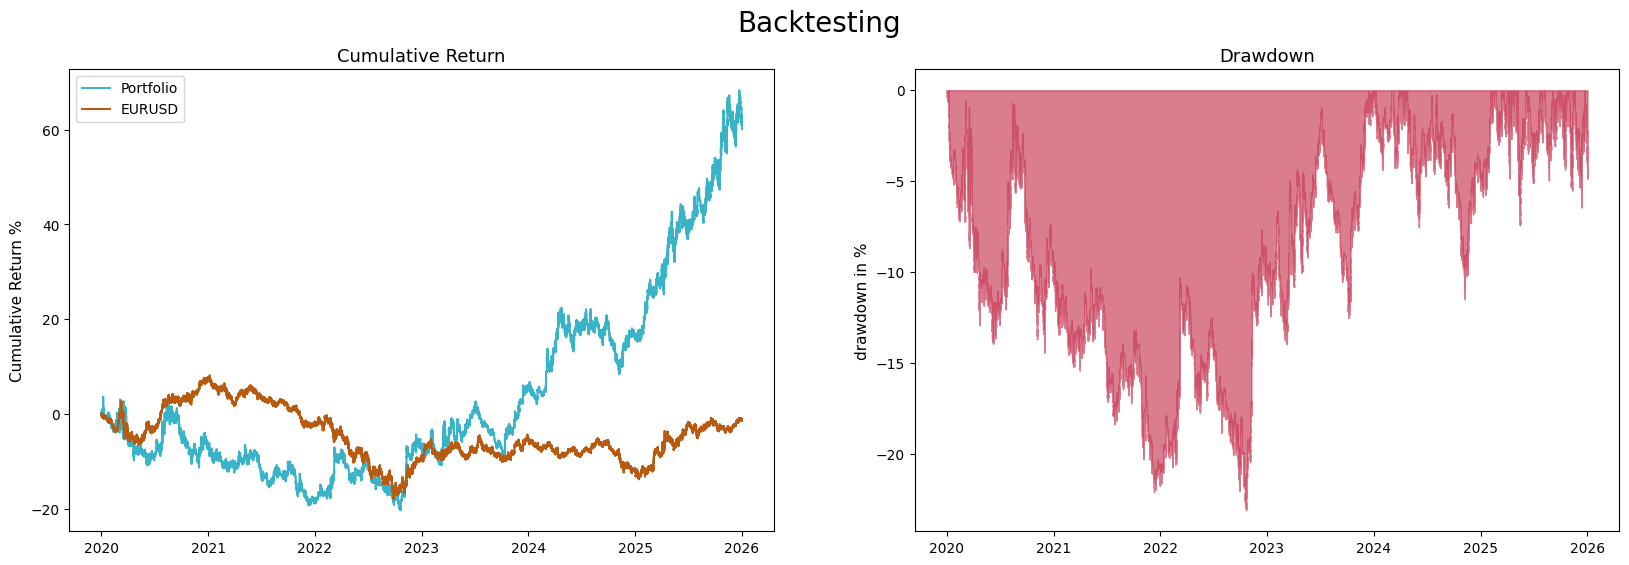

Final Return Portfolio: 60.08%
Final Return EURUSD: -1.29%
Sortino: 0.369
Beta: -0.001
Alpha: 9.243 %
MaxDrawdown: 23.123 %


In [21]:
# DonchianChannel strategy v3 with regime filter, volatility targeting, and time stop
import io
from contextlib import redirect_stdout
from itertools import product
import numpy as np
import pandas as pd


def DonchianChannel_strategy_v3(
    data,
    lower_length=30,
    upper_length=65,
    trend_length=150,
    exit_ema_length=50,
    atr_length=14,
    atr_stop_mult=2.0,
    atr_trail_mult=3.0,
    breakout_buffer=0.0,
    entry_confirm_bars=1,
    cooldown_bars=2,
    max_hold_bars=40,
    transaction_cost=0.00001,
    long_only=True,
    use_midline_exit=False,
    min_vol_quantile=0.25,
    target_daily_risk=0.01,
    max_leverage=2.0,
):
    df = data.copy()

    required_cols = {"close", "high", "low"}
    missing_cols = required_cols.difference(df.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

    close = df["close"]
    high = df["high"]
    low = df["low"]

    upper = high.rolling(upper_length).max().shift(1)
    lower = low.rolling(lower_length).min().shift(1)
    midline = (upper + lower) / 2.0

    trend_ma = close.rolling(trend_length).mean()
    exit_ema = close.ewm(span=exit_ema_length, adjust=False).mean()

    prev_close = close.shift(1)
    tr = pd.concat(
        [
            (high - low),
            (high - prev_close).abs(),
            (low - prev_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    atr = tr.rolling(atr_length).mean()

    ret = close.pct_change().fillna(0.0)
    vol = ret.rolling(20).std()
    vol_floor = vol.quantile(min_vol_quantile)
    regime_ok = (close > trend_ma) & (vol > vol_floor)

    returns = pd.Series(0.0, index=df.index)

    position = 0.0
    entry_price = np.nan
    bars_in_trade = 0
    cooldown = 0
    entry_hits = 0
    trail_stop = np.nan

    for i in range(1, len(df)):
        px = close.iloc[i]
        px_prev = close.iloc[i - 1]

        if pd.isna(upper.iloc[i]) or pd.isna(lower.iloc[i]) or pd.isna(atr.iloc[i]):
            continue

        if cooldown > 0:
            cooldown -= 1

        long_break = px > upper.iloc[i] * (1.0 + breakout_buffer)
        short_break = px < lower.iloc[i] * (1.0 - breakout_buffer)

        if long_break:
            entry_hits += 1
        else:
            entry_hits = 0

        # Mark-to-market return while in a position.
        if position != 0.0:
            returns.iloc[i] = position * (px / px_prev - 1.0)
            bars_in_trade += 1

            if not np.isnan(trail_stop):
                trail_stop = max(trail_stop, px - atr_trail_mult * atr.iloc[i])

            hard_stop = entry_price - atr_stop_mult * atr.iloc[i]
            stop_level = max(hard_stop, trail_stop) if not np.isnan(trail_stop) else hard_stop

            stop_exit = px < stop_level
            ema_exit = px < exit_ema.iloc[i]
            midline_exit = use_midline_exit and (px < midline.iloc[i])
            time_exit = bars_in_trade >= max_hold_bars

            if stop_exit or ema_exit or midline_exit or time_exit:
                returns.iloc[i] -= abs(position) * transaction_cost
                position = 0.0
                entry_price = np.nan
                bars_in_trade = 0
                trail_stop = np.nan
                cooldown = cooldown_bars
                entry_hits = 0
                continue

        # Entry logic (long side only by default).
        if position == 0.0 and cooldown == 0 and regime_ok.iloc[i] and entry_hits >= entry_confirm_bars:
            if long_only and not long_break:
                continue
            if (not long_only) and (not long_break) and (not short_break):
                continue

            atr_pct = atr.iloc[i] / px if px != 0 else np.nan
            if pd.isna(atr_pct) or atr_pct <= 0:
                continue

            sized_pos = target_daily_risk / atr_pct
            sized_pos = float(np.clip(sized_pos, 0.0, max_leverage))

            if long_break:
                position = sized_pos
                entry_price = px
                bars_in_trade = 0
                trail_stop = px - atr_trail_mult * atr.iloc[i]
                returns.iloc[i] -= abs(position) * transaction_cost

            elif (not long_only) and short_break:
                position = -sized_pos
                entry_price = px
                bars_in_trade = 0
                trail_stop = px + atr_trail_mult * atr.iloc[i]
                returns.iloc[i] -= abs(position) * transaction_cost

    return returns.fillna(0.0)


# Compact optimization for v3 controls
v3_grid = list(
    product(
        [25, 30],               # lower_length
        [60, 65, 70],           # upper_length
        [120, 150],             # trend_length
        [40, 50],               # exit_ema_length
        [0.0, 0.0001],          # breakout_buffer
        [1.8, 2.0],             # atr_stop_mult
        [2.8, 3.0],             # atr_trail_mult
        [30, 40],               # max_hold_bars
        [0.20, 0.25, 0.30],     # min_vol_quantile
        [0.008, 0.010, 0.012],  # target_daily_risk
    )
)

v3_results = []
print(f"Starting v3 optimization with {len(v3_grid)} combinations...")

for idx, (
    lower_len,
    upper_len,
    trend_len,
    exit_ema_len,
    breakout_buf,
    stop_mult,
    trail_mult,
    max_hold,
    min_vol_q,
    target_risk,
) in enumerate(v3_grid, start=1):
    if trail_mult <= stop_mult:
        continue

    try:
        r_v3 = DonchianChannel_strategy_v3(
            df_GOLD,
            lower_length=lower_len,
            upper_length=upper_len,
            trend_length=trend_len,
            exit_ema_length=exit_ema_len,
            atr_length=14,
            atr_stop_mult=stop_mult,
            atr_trail_mult=trail_mult,
            breakout_buffer=breakout_buf,
            entry_confirm_bars=1,
            cooldown_bars=2,
            max_hold_bars=max_hold,
            transaction_cost=0.00001,
            long_only=True,
            use_midline_exit=False,
            min_vol_quantile=min_vol_q,
            target_daily_risk=target_risk,
            max_leverage=2.0,
        )

        with redirect_stdout(io.StringIO()):
            m_v3 = BackTest(r_v3, df_baseline, selected_timeframe, plot=False)

        v3_results.append(
            {
                "lower_length": lower_len,
                "upper_length": upper_len,
                "trend_length": trend_len,
                "exit_ema_length": exit_ema_len,
                "breakout_buffer": breakout_buf,
                "atr_stop_mult": stop_mult,
                "atr_trail_mult": trail_mult,
                "max_hold_bars": max_hold,
                "min_vol_quantile": min_vol_q,
                "target_daily_risk": target_risk,
                "final_return_portfolio": m_v3["final_return_portfolio"],
                "sortino": m_v3["sortino"],
                "alpha": m_v3["alpha"],
                "max_drawdown": m_v3["max_drawdown"],
            }
        )

        if idx % 50 == 0:
            print(f"Processed {idx}/{len(v3_grid)} combinations")

    except Exception:
        continue

if not v3_results:
    print("No valid v3 combinations were produced.")
else:
    v3_results_df = pd.DataFrame(v3_results).sort_values("final_return_portfolio", ascending=False)

    print("\nTop 10 v3 results:")
    print(
        v3_results_df[
            [
                "final_return_portfolio",
                "sortino",
                "max_drawdown",
                "alpha",
                "lower_length",
                "upper_length",
                "trend_length",
                "exit_ema_length",
                "atr_stop_mult",
                "atr_trail_mult",
                "max_hold_bars",
                "min_vol_quantile",
                "target_daily_risk",
            ]
        ].head(10).to_string(index=False)
    )

    v3_best = v3_results_df.iloc[0]
    print("\nBest v3 parameters:")
    print(v3_best.to_string())

    print("\nRunning final backtest for best v3...\n")
    dfc_v3 = DonchianChannel_strategy_v3(
        df_GOLD,
        lower_length=int(v3_best["lower_length"]),
        upper_length=int(v3_best["upper_length"]),
        trend_length=int(v3_best["trend_length"]),
        exit_ema_length=int(v3_best["exit_ema_length"]),
        atr_length=14,
        atr_stop_mult=float(v3_best["atr_stop_mult"]),
        atr_trail_mult=float(v3_best["atr_trail_mult"]),
        breakout_buffer=float(v3_best["breakout_buffer"]),
        entry_confirm_bars=1,
        cooldown_bars=2,
        max_hold_bars=int(v3_best["max_hold_bars"]),
        transaction_cost=0.00001,
        long_only=True,
        use_midline_exit=False,
        min_vol_quantile=float(v3_best["min_vol_quantile"]),
        target_daily_risk=float(v3_best["target_daily_risk"]),
        max_leverage=2.0,
    )
    metrics_v3 = BackTest(dfc_v3, df_baseline, selected_timeframe)